In [40]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

'Shape: '

(41202, 13)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

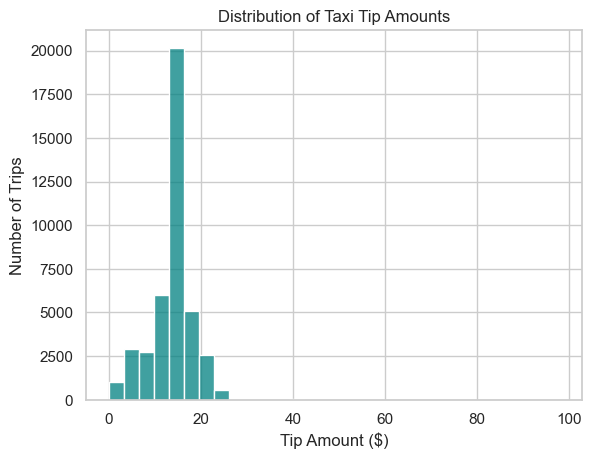

In [41]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
display("Shape: ", taxi.shape)
display(taxi.head())
taxi.info()

# - taxi.describe()
display(taxi.describe())
# - count missing values per column: taxi.isna().sum()

display(taxi.isna().sum())


# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(data=taxi, x="tip_amount", color="teal", bins=30)

plt.xlabel("Tip Amount ($)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Tip Amounts")

plt.show()

**Student Reasoning** — Taxi data exploration

What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

**Answer**: The dataset contains many taxi trips, with each row representing one trip and each column representing a feature such as fare amount, trip distance, and tip amount. There are no obvious missing values based on the initial inspection. The tip_amount variable is right-skewed, with most tips between approximately $5 and $20 and a few unusually large tips creating a long right tail. These outliers and the skewed distribution suggest that preprocessing should include checking for invalid values, handling outliers, and feature scaling before training machine learning models.


In [42]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()

# Remove impossible values
taxi = taxi[
    (taxi["trip_distance"] > 0) & (taxi["fare_amount"] > 0) & (taxi["tip_amount"] >= 0)
]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# Feature engineering
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

taxi["total_surcharge"] = (
    taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]
)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# One-hot encode categorical variables
taxi = pd.get_dummies(
    taxi,
    columns=["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"],
    drop_first=True,
)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

**Student Reasoning** — Taxi preprocessing

1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

**Answer**:

1. I first checked the dataset for missing values using isnull().sum(). Any rows with missing values were removed using dropna() to ensure the model was trained on complete data and that was ensured when I displayed display(taxi.isna().sum()). I also removed invalid records where trip_distance <= 0, fare_amount <= 0, or tip_amount < 0, since these values are unrealistic for taxi trips and could negatively affect the model's performance and accuracy.

2. I created fare_per_mile. This feature represents how much the passenger was charged per mile traveled. It may capture pricing patterns better than using fare amount or trip distance alone. I also created, total_surcharge by summing mta_tax, tolls_amount, and improvement_surcharge. This combines all additional charges into a single feature, which may help the model better understand the total cost of a trip. Importantly, I did not create any features using tip_amount because it is the target variable and doing so would cause data leakage.

3. I used StandardScaler to standardize the numerical features. StandardScaler transforms each feature so that it has a mean of 0 and a standard deviation of 1. This is appropriate because the numerical features (such as fare_amount, trip_distance, and fare_per_mile) have very different ranges. Scaling ensures that no single feature dominates the others due to its larger magnitude and can improve the performance of many machine learning algorithms. To avoid data leakage, the scaler was fitted only on the training data and then applied to the test data.


In [43]:
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Second split: 75% of the remaining data for training, 25% for validation
# This gives 60% train, 20% validation, 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

# List of numeric columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

# Scale numeric features
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 24675 | Test: 8226


**Student Reasoning** — Splitting

What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

**Answer**:
I used a 60/20/20 split for the dataset, meaning 60% of the data was used for training, 20% for validation, and 20% for testing. This is a common and balanced ratio that provides enough data for training the model while still keeping sufficient data for validation and final evaluation.

A separate validation set is useful because it allows us to tune model decisions (such as feature choices) without touching the test set. This helps prevent overfitting to the test data and ensures that the final evaluation is truly unbiased. The test set is only used once at the end to evaluate the final performance of the model on completely unseen data.

The scaler (and any imputation statistics) must be fit only on the training data to avoid data leakage. If we compute scaling values (such as mean and standard deviation) using the full dataset, information from the validation and test sets would indirectly influence the model during training. This would make the evaluation overly optimistic and not reflect real-world performance. By fitting only on the training set and applying the same transformation to validation and test sets, we ensure a fair and realistic evaluation.


Linear Regression:
Train: (np.float64(4.804452555330035), 0.05132795677510382)
Val: (np.float64(5.037135953076982), 0.04863478237663177)
Test: (np.float64(5.0131789527740915), 0.051062049212356686)
Random Forest:
Train: (np.float64(2.83613189341016), 0.6694165316835426)
Val: (np.float64(5.645954268710598), -0.1952386716764971)
Test: (np.float64(5.610968828629728), -0.18874064547401304)


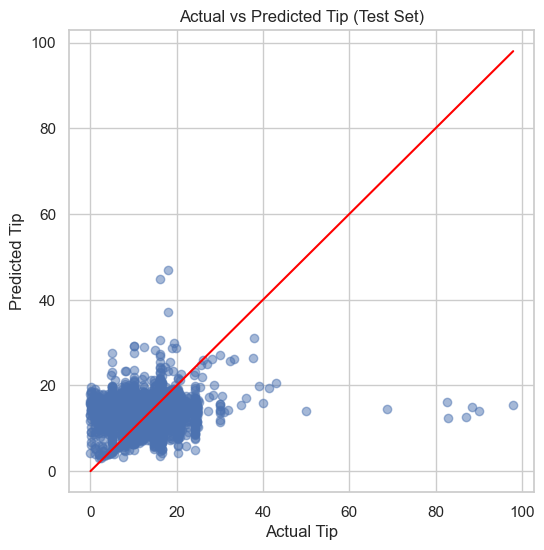

In [44]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# TODO: Predict on train, validation, and test sets.
# Linear Regression predictions
y_train_pred_lr = lin_reg.predict(X_train)
y_val_pred_lr = lin_reg.predict(X_val)
y_test_pred_lr = lin_reg.predict(X_test)

# Random Forest predictions
y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2


print("Linear Regression:")

print("Train:", evaluate(y_train, y_train_pred_lr))
print("Val:", evaluate(y_val, y_val_pred_lr))
print("Test:", evaluate(y_test, y_test_pred_lr))

print("Random Forest:")

print("Train:", evaluate(y_train, y_train_pred_rf))
print("Val:", evaluate(y_val, y_val_pred_rf))
print("Test:", evaluate(y_test, y_test_pred_rf))

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred_rf, alpha=0.5)

# y = x line (perfect prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip (Test Set)")

plt.show()

**Student Reasoning** — Regression evaluation & overfitting

1. Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

**Answer**:

I compared Linear Regression and Random Forest Regressor. For the Random Forest model, I used the default hyperparameters with random_state=42. Based on the validation results, Linear Regression performed better because it achieved a lower RMSE (5.04 vs. 5.65) and a higher R² (0.049 vs. -0.195) than the Random Forest model.

The Linear Regression model performed consistently across the training, validation, and test sets:
| Dataset | RMSE | R² |
| ---------- | -------- | --------- |
| Train | **4.80** | **0.051** |
| Validation | **5.04** | **0.049** |
| Test | **5.01** | **0.051** |

The metrics are very similar across all three datasets, indicating that the model is not overfitting. However, the R² values are very low (around 0.05), meaning the model explains only about 5% of the variation in tip amounts. This suggests the model is underfitting, as it is too simple to capture the relationship between the features and the target.

The Random Forest model shows clear signs of overfitting:

| Dataset    | RMSE     | R²         |
| ---------- | -------- | ---------- |
| Train      | **2.84** | **0.669**  |
| Validation | **5.65** | **-0.195** |
| Test       | **5.61** | **-0.189** |

The training performance is much better than the validation and test performance. The R² drops from 0.669 on the training set to approximately -0.19 on both the validation and test sets. This large gap indicates that the Random Forest learned the training data very well but failed to generalize to unseen data, which is a strong indication of overfitting.

To reduce overfitting, I would tune the Random Forest hyperparameters instead of using the defaults. For example, I could reduce the maximum depth of the trees (max_depth), increase the minimum number of samples required to split a node (min_samples_split), increase the minimum number of samples required in a leaf (min_samples_leaf), or reduce the number of features considered at each split (max_features). I could also perform cross-validation and use grid search or random search to find better hyperparameter values. These changes can help the model generalize better to unseen data.

Also, the scatter plot also supports this conclusion. Most predictions are concentrated between about 5 and 20, even when the actual tips are much larger (up to nearly 100). This means the model struggles to predict unusually high tip amounts, which is one reason the overall R² is low.


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

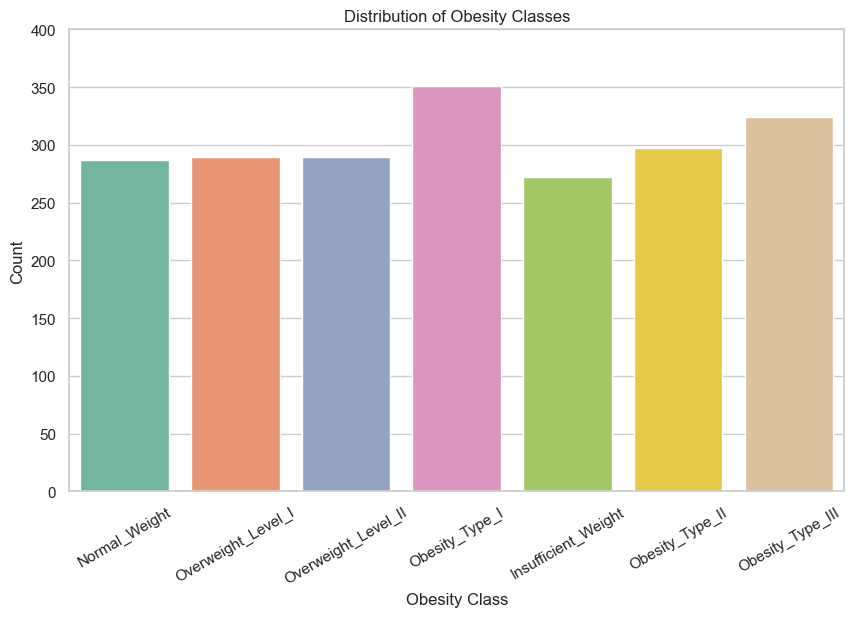

In [45]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
display(obesity.head())
obesity.info()

display(obesity.describe())

display(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
# Class distribution
display(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 6))

sns.countplot(
    data=obesity, x="NObeyesdad", hue="NObeyesdad", palette="Set2", legend=False
)

plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Class")
plt.ylabel("Count")
plt.ylim(0, 400)

plt.xticks(rotation=30)
plt.show()

**Student Reasoning** — Obesity data exploration

How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

The obesity dataset contains 2,111 rows (observations) and 17 columns (features). The dataset consists of both categorical and numerical variables.

**Categorical/Qualitative Variables**: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad

**Numerical/Quantitative Variables**: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

The classes are reasonably balanced, as the number of samples in each class ranges from 272 to 351. Although the classes are not perfectly equal, there is no severe class imbalance.

Class balance is important in classification because a heavily imbalanced dataset can cause a model to favor the majority classes while performing poorly on the minority classes. A reasonably balanced dataset allows the model to learn all classes more fairly and provides more reliable evaluation metrics, especially for accuracy, and precision.


In [46]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

obesity["Gender"] = obesity["Gender"].map({"Male": 1, "Female": 0})


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

ordinal = OrdinalEncoder()

obesity[["CAEC", "CALC"]] = ordinal.fit_transform(
    obesity[["CAEC", "CALC"]]
)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

**Student Reasoning** — Obesity preprocessing

1. How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?

**Answer**:

1. The binary categorical variables (family_history_with_overweight, FAVC, SMOKE, and SCC) were encoded as 0 and 1 because they only contain two possible values (Yes/No). Gender was also encoded as 0 and 1 since it has two categories (Male/Female). The CAEC and CALC variables were treated as ordinal because their categories have a natural order (e.g., No, Sometimes, Frequently, Always). The MTRANS variable was one-hot encoded because it is a nominal variable with no natural ordering, allowing each transportation mode to be represented without implying any order.

2. Yes. I engineered a new feature called BMI (Body Mass Index) using the formula. BMI= Weight / (Height \*\*2), BMI is a well-known indicator used to assess body weight relative to height and is strongly associated with obesity. It is fair to include because it is calculated only from existing input features (Weight and Height) and does not directly use the target variable (NObeyesdad). However, since obesity levels are closely related to BMI, including it makes the classification task easier by providing a more informative feature.

3. I used StandardScaler to scale the numerical features. StandardScaler standardizes each feature by subtracting its mean and dividing by its standard deviation, resulting in features with a mean of 0 and a standard deviation of 1. This ensures that numerical features with larger ranges do not dominate those with smaller ranges and helps many machine learning algorithms train more effectively. The scaler was fitted only on the training set and then applied to the validation and test sets to prevent data leakage.


In [47]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 25% of 80% = 20%
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

# Fit only on the training data
scaler.fit(X_train[numeric_cols])

# Transform all datasets
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**Student Reasoning** — Splitting
What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

I split the dataset into 60% training, 20% validation, and 20% testing. The training set is used to train the model, the validation set is used to tune the model and compare different algorithms or hyperparameters, and the test set is used to evaluate the final model on unseen data.

I used stratify=y when splitting the data because the target variable (NObeyesdad) contains 7 different obesity classes. Stratification ensures that each split contains approximately the same proportion of each class as the original dataset.

If I split the data without stratifying, some classes could be underrepresented or even missing in the training, validation, or test sets. This could make the model perform poorly on those classes and lead to an unfair or unreliable evaluation. Stratifying helps produce a more representative dataset and more trustworthy performance metrics.

In [48]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

classifier = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

classifier.fit(X_train, y_train)

rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

# TODO: Predict on train, validation, and test.
y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)
y_test_pred = classifier.predict(X_test)

rf_y_train_pred = rf.predict(X_train)
rf_y_val_pred = rf.predict(X_val)
rf_y_test_pred = rf.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# Logistic Regression
print("Logistic Regression")

print("Training Set")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Macro F1:", f1_score(y_train, y_train_pred, average="macro"))

print("\nValidation Set")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Macro F1:", f1_score(y_val, y_val_pred, average="macro"))

print("\nTest Set")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Macro F1:", f1_score(y_test, y_test_pred, average="macro"))

print("\nClassification Report (Test Set)")
print(classification_report(y_test, y_test_pred))

# Random Forest Classifier
print("Random Forest Classifier")

print("Training Set")
print("Accuracy:", accuracy_score(y_train, rf_y_train_pred))
print("Macro F1:", f1_score(y_train, rf_y_train_pred, average="macro"))

print("\nValidation Set")
print("Accuracy:", accuracy_score(y_val, rf_y_val_pred))
print("Macro F1:", f1_score(y_val, rf_y_val_pred, average="macro"))

print("\nTest Set")
print("Accuracy:", accuracy_score(y_test, rf_y_test_pred))
print("Macro F1:", f1_score(y_test, rf_y_test_pred, average="macro"))

print("\nClassification Report (Test Set)")
print(classification_report(y_test, rf_y_test_pred))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_test_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix (Test Set)")
plt.show()

ValueError: could not convert string to float: 'Public_Transportation'

**Student Reasoning** — Classification evaluation & overfitting 

1. Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

**Answer**:

1. 

In [ ]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.